<a href="https://colab.research.google.com/github/Loopinlogix/NLP_Clustering/blob/main/NLP_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:

# Github

# Clone a public GitHub repository
!git clone https://github.com/Loopinlogix/NLP_Clustering.git

# Change directory into the cloned repository (replace 'colabtools' with your repo name)
%cd NLP_Clustering

# List the contents of the directory
!ls

Cloning into 'NLP_Clustering'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/NLP_Clustering
README.md


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   NLP CLUSTERING - 20 NEWSGROUPS DATASET

Dataset loaded successfully!
Total documents: 18846
Number of categories: 20

Example categories:
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball']
STEP 1: Exploratory Data Analysis

Category distribution:
category
rec.sport.hockey            999
soc.religion.christian      997
rec.motorcycles             996
rec.sport.baseball          994
sci.crypt                   991
rec.autos                   990
sci.med                     990
comp.windows.x              988
sci.space                   987
comp.os.ms-windows.misc     985
sci.electronics             984
comp.sys.ibm.pc.hardware    982
misc.forsale                975
comp.graphics               973
comp.sys.mac.hardware       963
talk.politics.mideast       940
talk.politics.guns          910
alt.atheism                 799
talk.politics.m

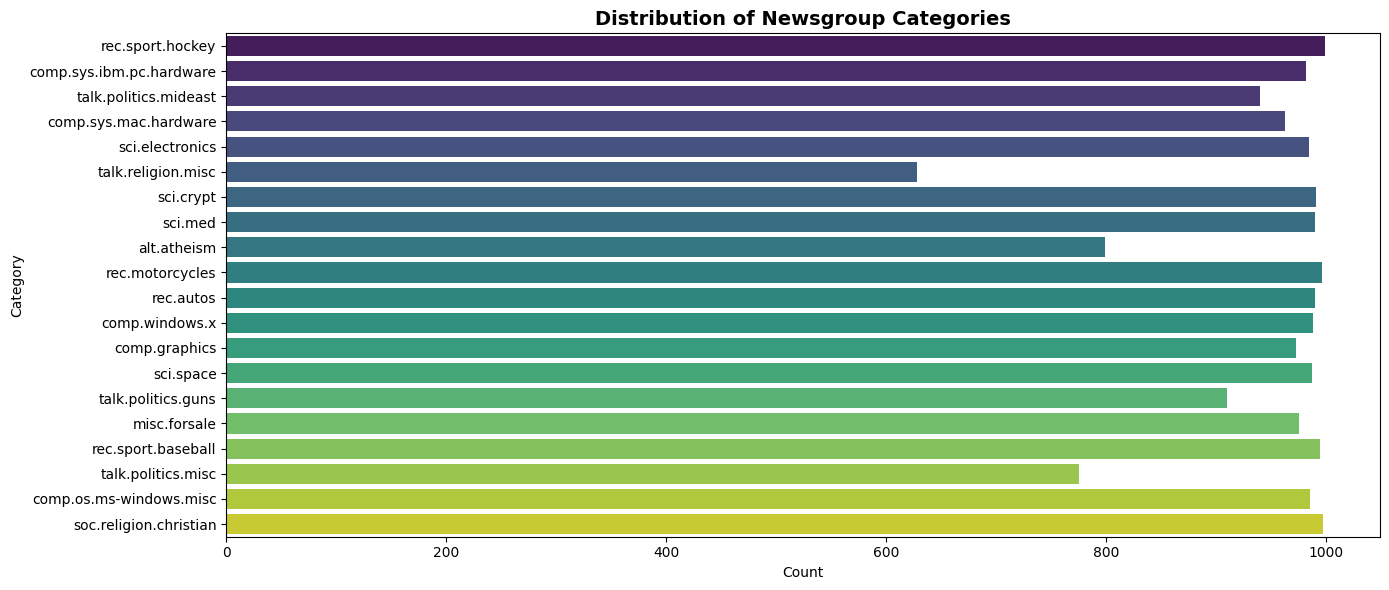

STEP 2: Text Preprocessing

Cleaning text data...

Sample cleaned text:
sure bashers pens fans pretty confused lack kind posts recent pens massacre devils actually bit puzzled bit relieved however going put end nonpittsburghers relief bit praise pens man killing devils worse thought jagr showed much better regular season stats also lot fun watch playoffs bowman let jagr

STEP 4: FEATURE ENGINEERING - VECTORIZATION

--- 4.1 Bag of Words ---
BoW shape: (5000, 5000)

--- 4.2 TF-IDF ---
TF-IDF shape: (5000, 5000)

Sample TF-IDF features: ['000' '0167' '0182' '0200' '0250' '0267' '0273' '0286' '0300' '0333'
 '0400' '0500' '100' '1000' '10000' '100000' '101' '102' '1024' '1024x768']
STEP 5: Word Visualization - BERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Generating embeddings...


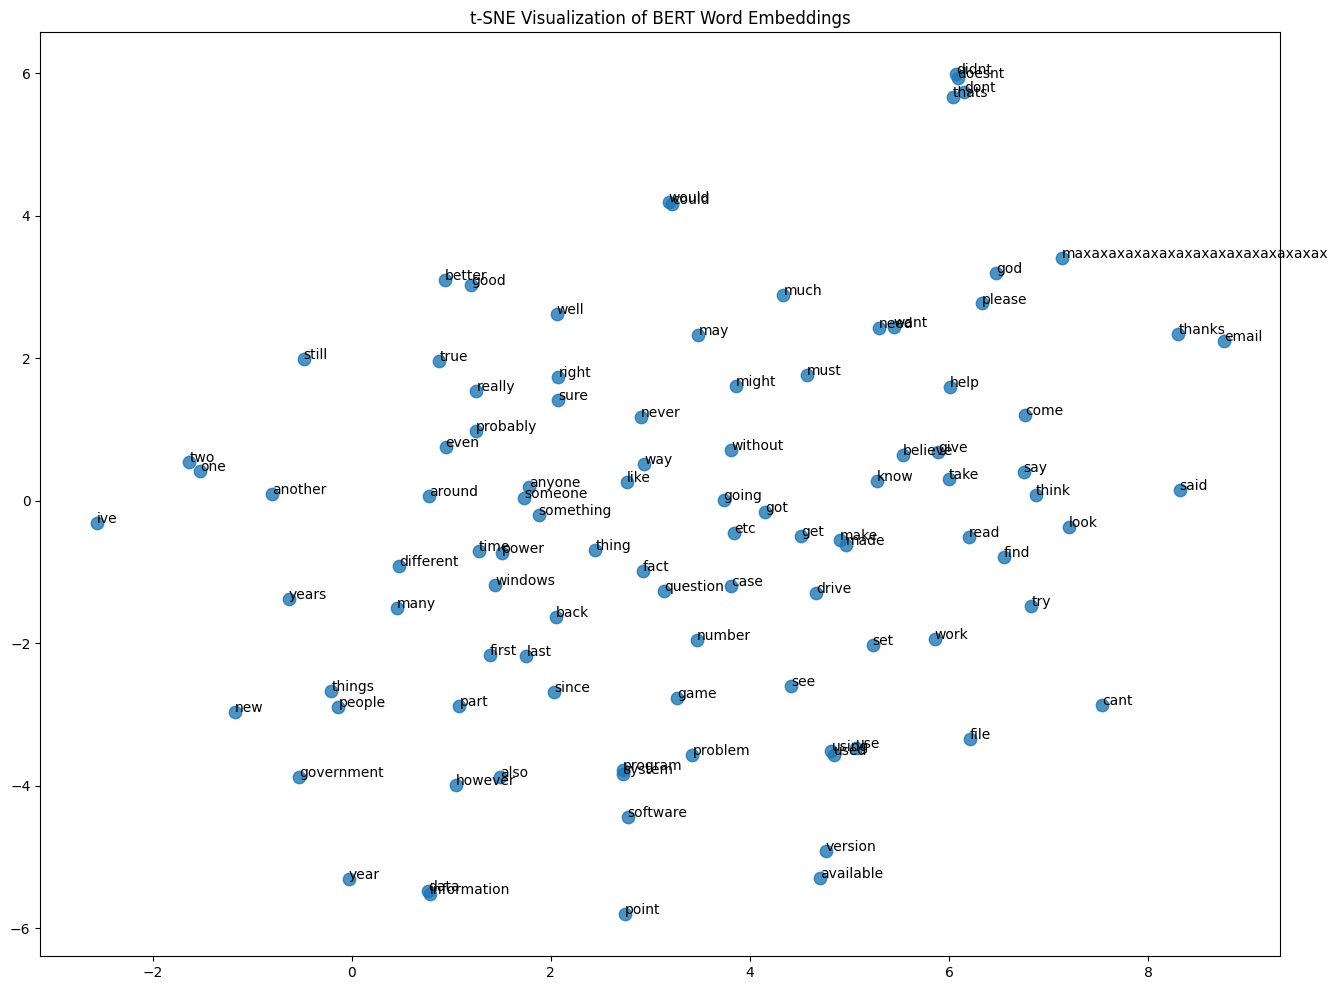


STEP 6: UNSUPERVISED LEARNING - CLUSTERING

Training K-Means...
K-Means completed!
Cluster counts: [ 141  310  142  391  274  180  128  174  107  211  246  227  317  140
   55  160 1277   78  292  150]

STEP 7: CLUSTER ANALYSIS

Cluster 0 top terms:
['window', 'server', 'code', 'display', 'application', 'running', 'using', 'motif', 'widget', 'use']

Cluster 1 top terms:
['would', 'like', 'know', 'get', 'anyone', 'think', 'one', 'much', 'could', 'help']

Cluster 2 top terms:
['drive', 'scsi', 'drives', 'disk', 'ide', 'hard', 'controller', 'floppy', 'mac', 'software']

Cluster 3 top terms:
['dont', 'people', 'think', 'know', 'like', 'much', 'get', 'well', 'one', 'something']

Cluster 4 top terms:
['thanks', 'please', 'email', 'anyone', 'advance', 'know', 'address', 'looking', 'send', 'info']

STEP 8: MODEL EVALUATION

Silhouette Score: -0.0002

STEP 9: PREDICTING NEW DOCUMENT CLUSTERS

Document: The graphics card performance in Linux is amazing.
Predicted Cluster: 7
Top terms: ['windows

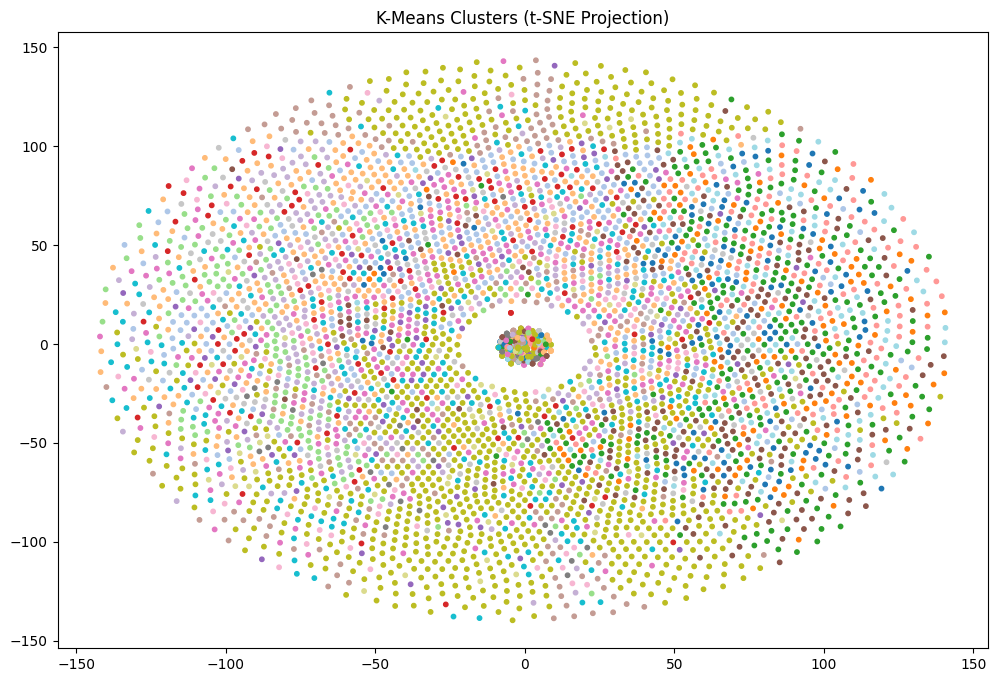


STEP 10: PREDICTED CLUSTER VISUALIZATION


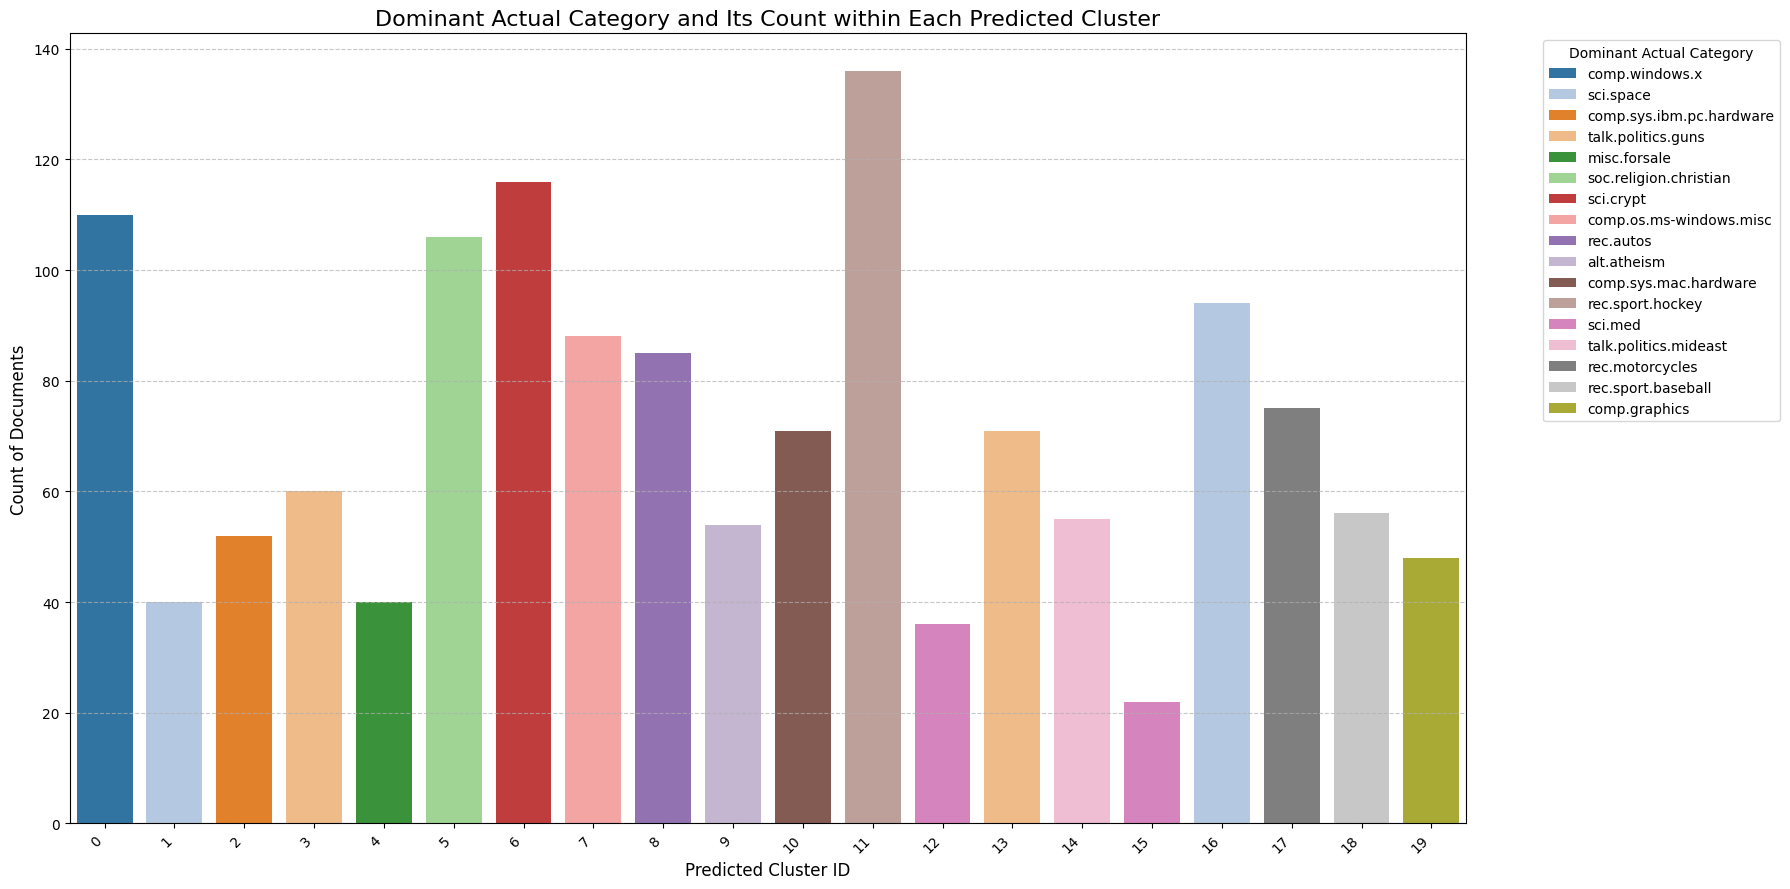

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('english')

print("=" * 60)
print("   NLP CLUSTERING - 20 NEWSGROUPS DATASET")
print("=" * 60)

# Load dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'))
texts = newsgroups.data
targets = newsgroups.target
target_names = newsgroups.target_names

print("\nDataset loaded successfully!")
print(f"Total documents: {len(texts)}")
print(f"Number of categories: {len(target_names)}")
print("\nExample categories:")
print(target_names[:10])

print("=" * 60)
print("STEP 1: Exploratory Data Analysis")
print("=" * 60)


df = pd.DataFrame({
    'text': texts,
    'target': targets
})
df['category'] = df['target'].apply(lambda x: target_names[x])

print("\nCategory distribution:")
print(df['category'].value_counts())

plt.figure(figsize=(14,6))
sns.countplot(data=df, y='category', palette='viridis')
plt.title("Distribution of Newsgroup Categories", fontsize=14, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

print("=" * 60)
print("STEP 2: Text Preprocessing")
print("=" * 60)

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = ''.join(ch for ch in text if ch not in string.punctuation)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("\nCleaning text data...")
df['cleaned'] = df['text'].apply(preprocess_text)

print("\nSample cleaned text:")
print(df['cleaned'].iloc[0][:300])

print("\n" + "=" * 60)
print("STEP 4: FEATURE ENGINEERING - VECTORIZATION")
print("=" * 60)

SAMPLE_SIZE = 5000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

X = df_sample['cleaned']

# Bag of Words
print("\n--- 4.1 Bag of Words ---")
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(X)
print("BoW shape:", X_bow.shape)

# TF-IDF
print("\n--- 4.2 TF-IDF ---")
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(X)
print("TF-IDF shape:", X_tfidf.shape)

feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nSample TF-IDF features:", feature_names[:20])

print("=" * 60)
print("STEP 5: Word Visualization - BERT")
print("=" * 60)


from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

top_n = 100
word_counts = np.asarray(X_bow.sum(axis=0)).flatten()
top_indices = np.argsort(word_counts)[-top_n:]
top_words = [feature_names[i] for i in top_indices]

def get_embedding(word):
    inputs = tokenizer(word, return_tensors="pt")
    outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).detach().numpy().flatten()

print("\nGenerating embeddings...")
bert_vectors = np.vstack([get_embedding(w) for w in top_words])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(bert_vectors)

plt.figure(figsize=(16,12))
plt.scatter(emb_2d[:,0], emb_2d[:,1], s=80, alpha=0.8)
for i, word in enumerate(top_words):
    plt.annotate(word, (emb_2d[i,0], emb_2d[i,1]))
plt.title("t-SNE Visualization of BERT Word Embeddings")
plt.show()

print("\n" + "=" * 60)
print("STEP 6: UNSUPERVISED LEARNING - CLUSTERING")
print("=" * 60)

n_clusters = 20

print("\nTraining K-Means...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_tfidf)

print("K-Means completed!")
print("Cluster counts:", np.bincount(labels_kmeans))

print("\n" + "=" * 60)
print("STEP 7: CLUSTER ANALYSIS")
print("=" * 60)

cluster_centers = kmeans.cluster_centers_

def top_terms(cluster_id, n=10):
    center = cluster_centers[cluster_id]
    indices = np.argsort(center)[::-1][:n]
    return [feature_names[i] for i in indices]

for c in range(5):
    print(f"\nCluster {c} top terms:")
    print(top_terms(c))

print("\n" + "=" * 60)
print("STEP 8: MODEL EVALUATION")
print("=" * 60)

sil_score = silhouette_score(X_tfidf, labels_kmeans)
print(f"\nSilhouette Score: {sil_score:.4f}")

print("\n" + "=" * 60)
print("STEP 9: PREDICTING NEW DOCUMENT CLUSTERS")
print("=" * 60)

new_docs = [
    "The graphics card performance in Linux is amazing.",
    "Jesus and faith are central to my life.",
    "The government should reduce taxes."
]

new_clean = [preprocess_text(t) for t in new_docs]
new_vec = tfidf_vectorizer.transform(new_clean)
pred_clusters = kmeans.predict(new_vec)

for doc, cluster in zip(new_docs, pred_clusters):
    print("\nDocument:", doc)
    print("Predicted Cluster:", cluster)
    print("Top terms:", top_terms(cluster))


print("\n" + "=" * 60)
print("STEP 10: VISUALIZATION")
print("=" * 60)

X_dense = X_tfidf.toarray()
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X_dense)

plt.figure(figsize=(12,8))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_kmeans, cmap='tab20', s=10)
plt.title("K-Means Clusters (t-SNE Projection)")
plt.show()

print("\n" + "=" * 60)
print("STEP 10: PREDICTED CLUSTER VISUALIZATION")
print("=" * 60)

# Add predicted cluster labels to the sampled DataFrame
df_sample['predicted_cluster'] = labels_kmeans

# Group by predicted cluster and actual category, then count occurrences
cluster_category_distribution = df_sample.groupby(['predicted_cluster', 'category']).size().reset_index(name='count')

# Find the dominant actual category for each predicted cluster
dominant_categories_per_cluster = cluster_category_distribution.loc[
    cluster_category_distribution.groupby('predicted_cluster')['count'].idxmax()
].reset_index(drop=True)

# Sort by predicted_cluster for consistent plotting
dominant_categories_per_cluster = dominant_categories_per_cluster.sort_values(by='predicted_cluster')

# Visualize the dominant category for each cluster
plt.figure(figsize=(18, 9))
sns.barplot(x='predicted_cluster', y='count', hue='category', data=dominant_categories_per_cluster, palette='tab20', dodge=False)
plt.title('Dominant Actual Category and Its Count within Each Predicted Cluster', fontsize=16)
plt.xlabel('Predicted Cluster ID', fontsize=12)
plt.ylabel('Count of Documents', fontsize=12)
plt.xticks(range(n_clusters), rotation=45, ha='right') # Ensure all cluster IDs are visible and readable
plt.legend(title='Dominant Actual Category', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()